In [1]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("/kaggle/input/datasets/lfreedom2750/coffee-price-dataset/next_day_price_label/robusta_original_features.csv")

# Bỏ cột không dùng
df_drop_date = df.drop(columns=["date"])

# Xóa các dòng NaN do rolling/lag
df_drop_date = df_drop_date.dropna().reset_index(drop=True)

# Tách X và y
X = df_drop_date.drop(columns=["target_next_day"])
y = df_drop_date["target_next_day"]

# Chia dữ liệu theo thời gian
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size + val_size]
y_val = y.iloc[train_size:train_size + val_size]

X_test = X.iloc[train_size + val_size:]
y_test = y.iloc[train_size + val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(521, 7)
(111, 7)
(110, 7)


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# CROSS VALIDATION
# =========================
tscv = TimeSeriesSplit(n_splits=5)

# =========================
# HYPERPARAMETER GRID
# =========================
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# =========================
# MODEL
# =========================
rf_model = RandomForestRegressor(random_state=42)

# =========================
# GRID SEARCH
# =========================
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
rf_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_rf = rf_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_random_forest.pkl")

joblib.dump(best_rf, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_rf = best_rf.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_rf)
mse = mean_squared_error(y_test, pred_rf)
rmse = np.sqrt(mse)

print("Best Params:", rf_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model saved to: checkpoints/best_random_forest.pkl
Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
MAE  : 2115.2967
MSE  : 7093406.0992
RMSE : 2663.3449


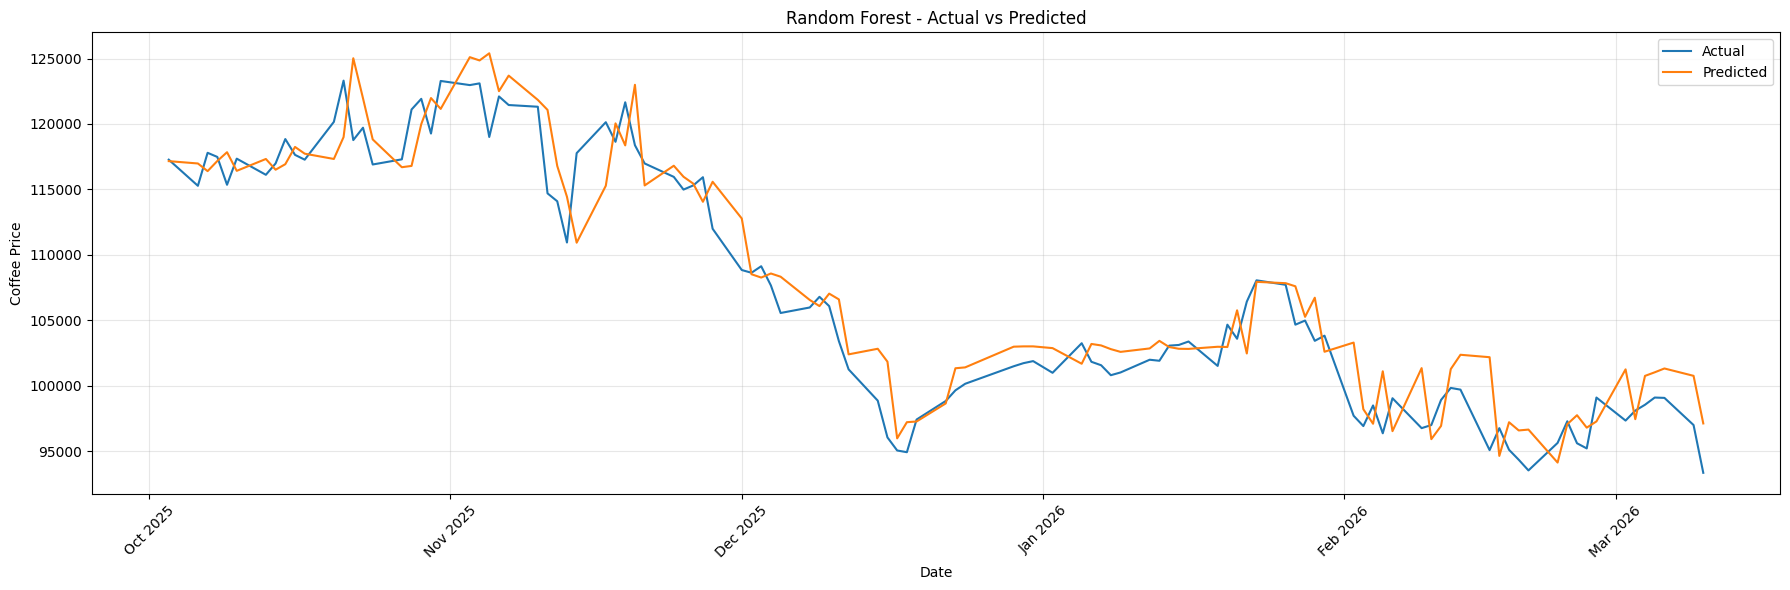

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_rf,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("Random Forest - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

# =========================
# MODEL
# =========================
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
xgb_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_xgb = xgb_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_xgboost.pkl")

joblib.dump(best_xgb, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_xgb = best_xgb.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_xgb)
mse = mean_squared_error(y_test, pred_xgb)
rmse = np.sqrt(mse)

print("Best Params:", xgb_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model saved to: checkpoints/best_xgboost.pkl
Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
MAE  : 2424.6230
MSE  : 9328274.9114
RMSE : 3054.2225


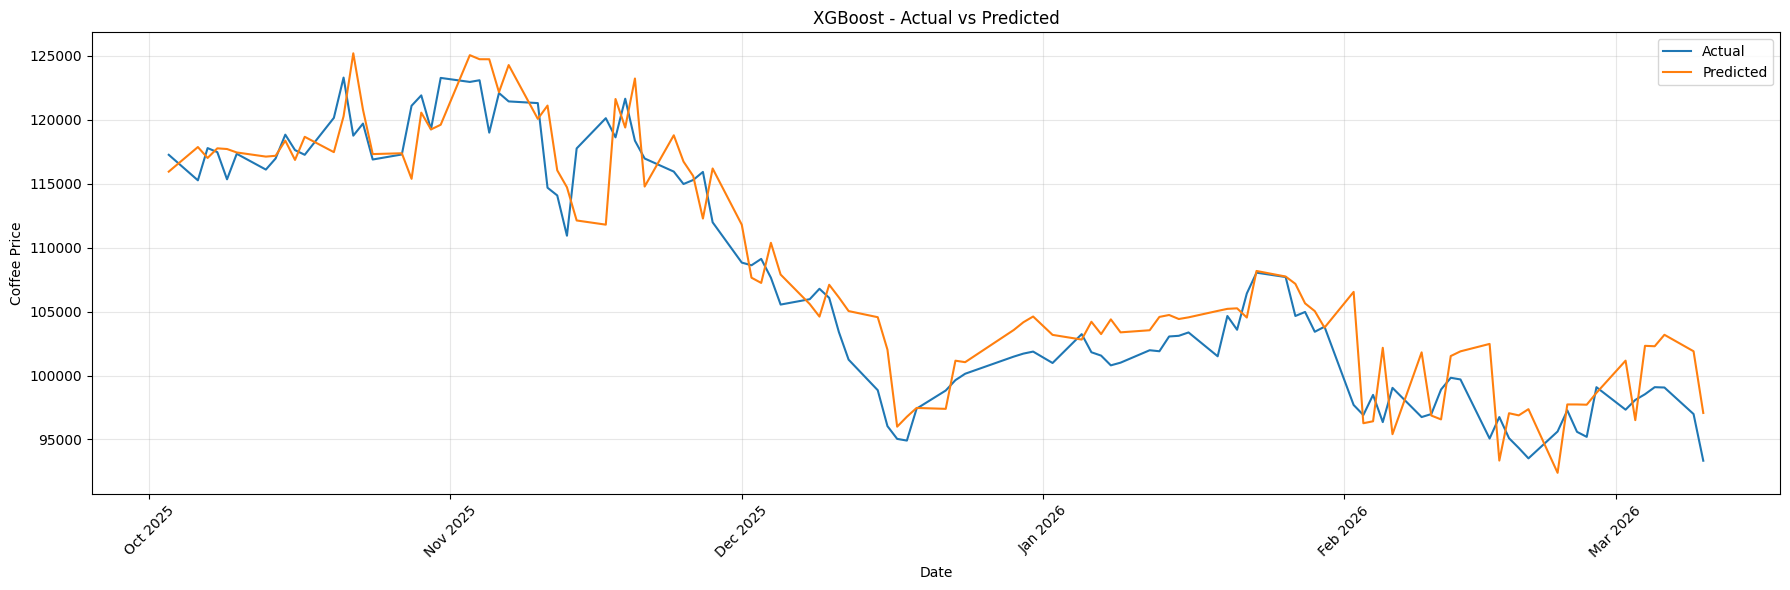

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_xgb,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("XGBoost - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [6]:
# =========================
# CELL 3 — LIGHTGBM
# =========================

from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
lgbm_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50]
}

# =========================
# MODEL
# =========================
lgbm_model = LGBMRegressor(random_state=42)

# =========================
# GRID SEARCH
# =========================
lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
lgbm_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_lgbm = lgbm_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_lightgbm.pkl")

joblib.dump(best_lgbm, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_lgbm = best_lgbm.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_lgbm)
mse = mean_squared_error(y_test, pred_lgbm)
rmse = np.sqrt(mse)

print("Best Params:", lgbm_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 91, number of used features: 7
[LightGBM] [Info] Start training from score 66127.652129
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

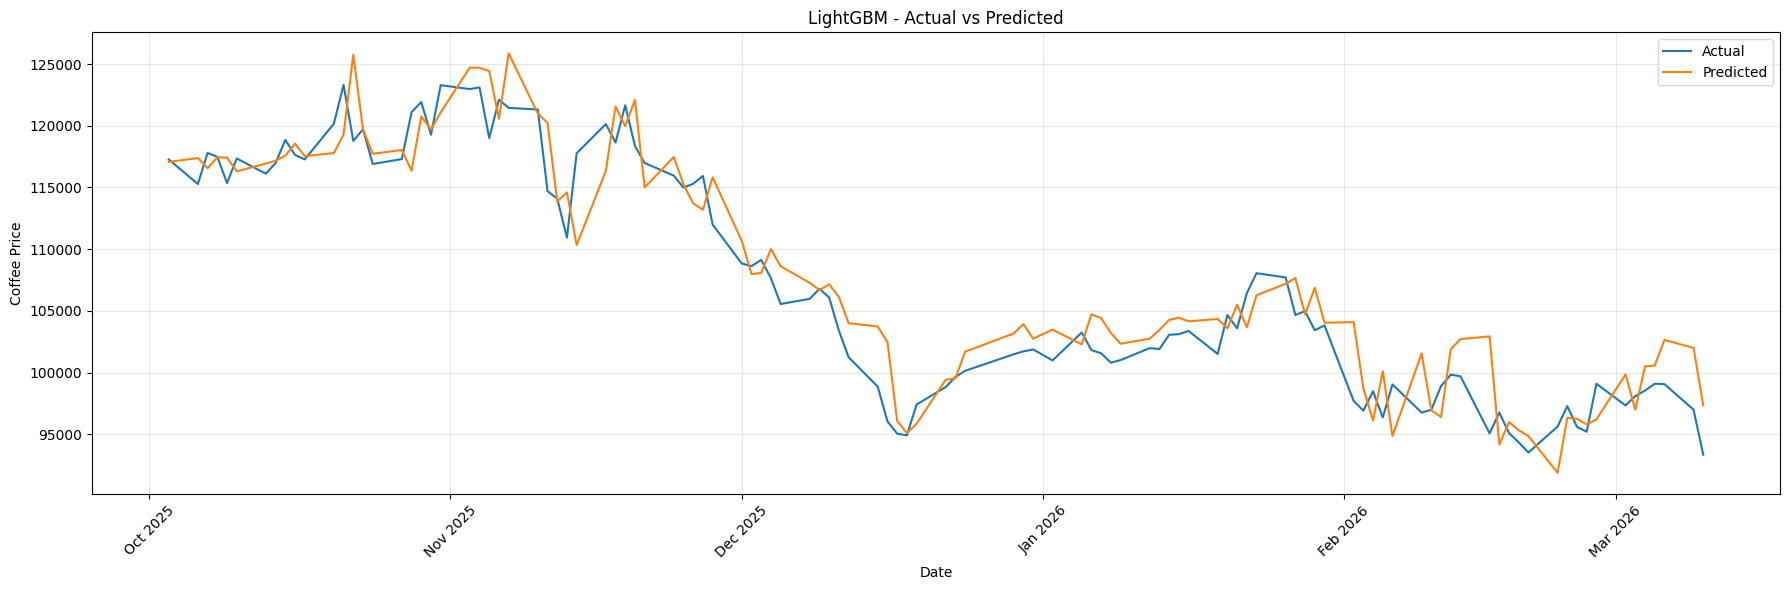

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_lgbm,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("LightGBM - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [8]:
# =========================
# CELL 4 — CATBOOST
# =========================

from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
cat_params = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [100, 200]
}

# =========================
# MODEL
# =========================
cat_model = CatBoostRegressor(
    verbose=0,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
cat_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_cat = cat_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_catboost.pkl")

joblib.dump(best_cat, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_cat = best_cat.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_cat)
mse = mean_squared_error(y_test, pred_cat)
rmse = np.sqrt(mse)

print("Best Params:", cat_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Model saved to: checkpoints/best_catboost.pkl
Best Params: {'depth': 4, 'iterations': 200, 'learning_rate': 0.1}
MAE  : 2175.5589
MSE  : 7333620.1423
RMSE : 2708.0658


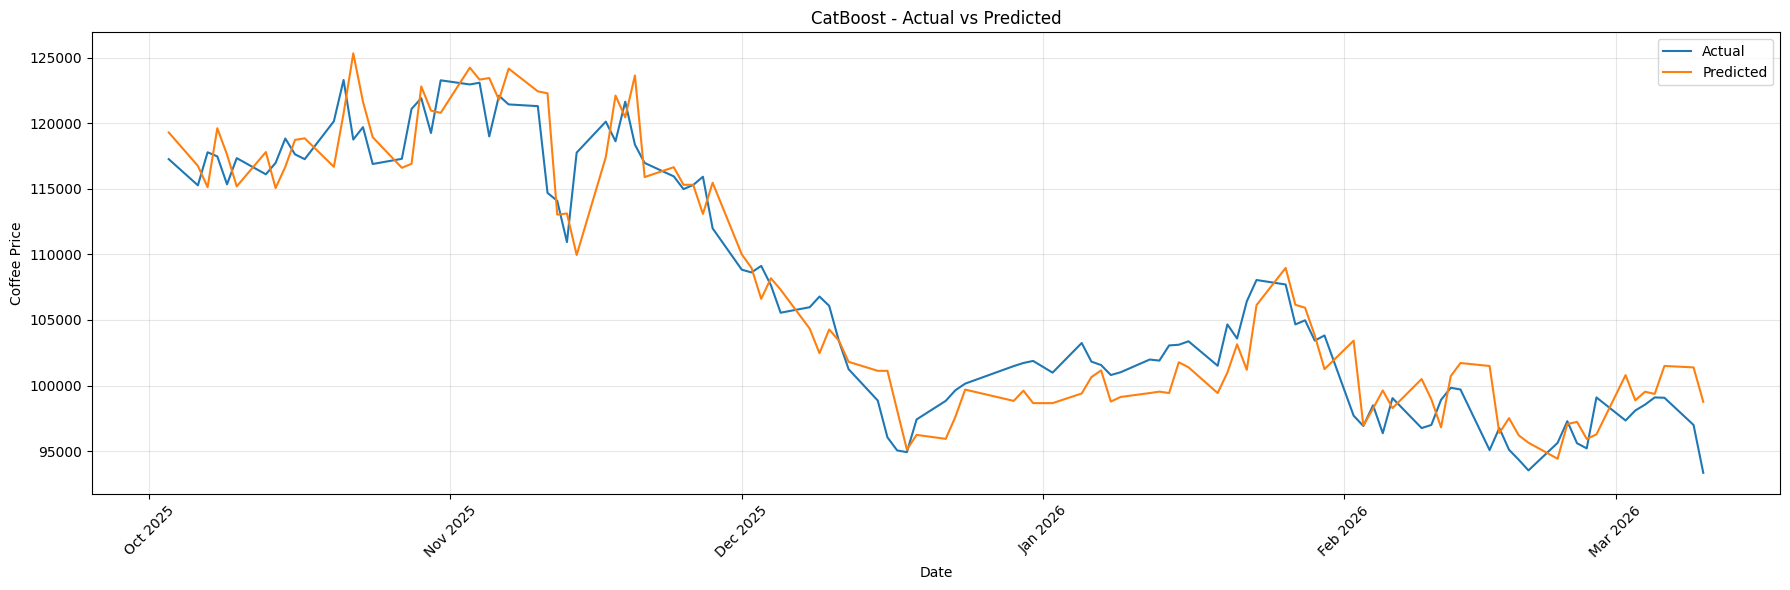

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_cat,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("CatBoost - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [10]:
# =========================
# CELL 5 — LASSO
# =========================

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import os

# =========================
# SCALE DATA
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# HYPERPARAMETER GRID
# =========================
lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

# =========================
# MODEL
# =========================
lasso_model = Lasso(
    max_iter=10000,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
lasso_grid = GridSearchCV(
    estimator=lasso_model,
    param_grid=lasso_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
lasso_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_lasso = lasso_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_lasso.pkl")
joblib.dump(best_lasso, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "lasso_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_lasso = best_lasso.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_lasso)
mse = mean_squared_error(y_test, pred_lasso)
rmse = np.sqrt(mse)

print("Best Params:", lasso_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Model saved to: checkpoints/best_lasso.pkl
Scaler saved to: checkpoints/lasso_scaler.pkl
Best Params: {'alpha': 0.1}
MAE  : 1755.2738
MSE  : 5285331.4361
RMSE : 2298.9849


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.376e+07, tolerance: 1.131e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.132e+08, tolerance: 2.662e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.173e+08, tolerance: 1.180e

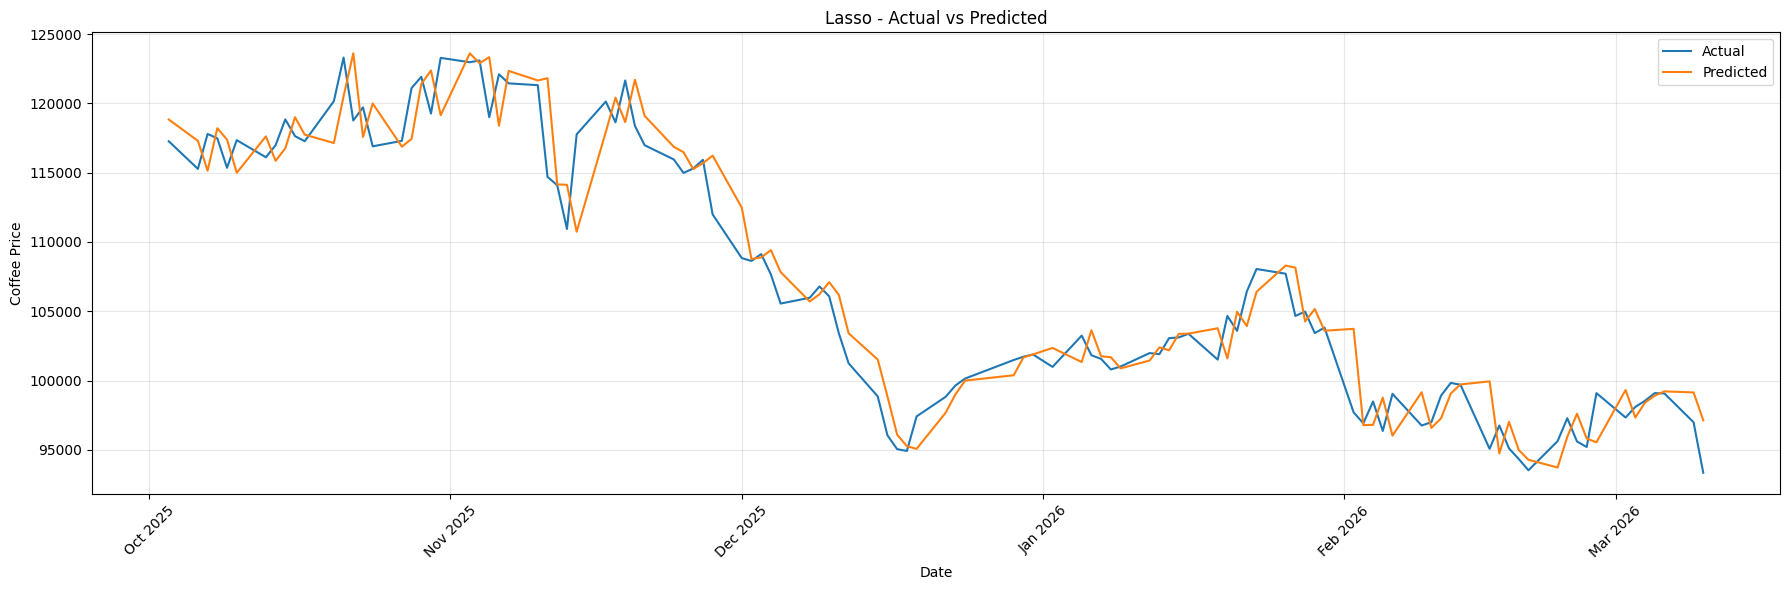

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_lasso,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("Lasso - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [12]:
# =========================
# CELL — RIDGE REGRESSION
# =========================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
ridge_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
}

# =========================
# MODEL
# =========================
ridge_model = Ridge(
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
ridge_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_ridge = ridge_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_ridge.pkl")
joblib.dump(best_ridge, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "ridge_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_ridge = best_ridge.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_ridge)
mse = mean_squared_error(y_test, pred_ridge)
rmse = np.sqrt(mse)

print("Best Params:", ridge_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Model saved to: checkpoints/best_ridge.pkl
Scaler saved to: checkpoints/ridge_scaler.pkl
Best Params: {'alpha': 0.001}
MAE  : 1754.9417
MSE  : 5281770.1853
RMSE : 2298.2102


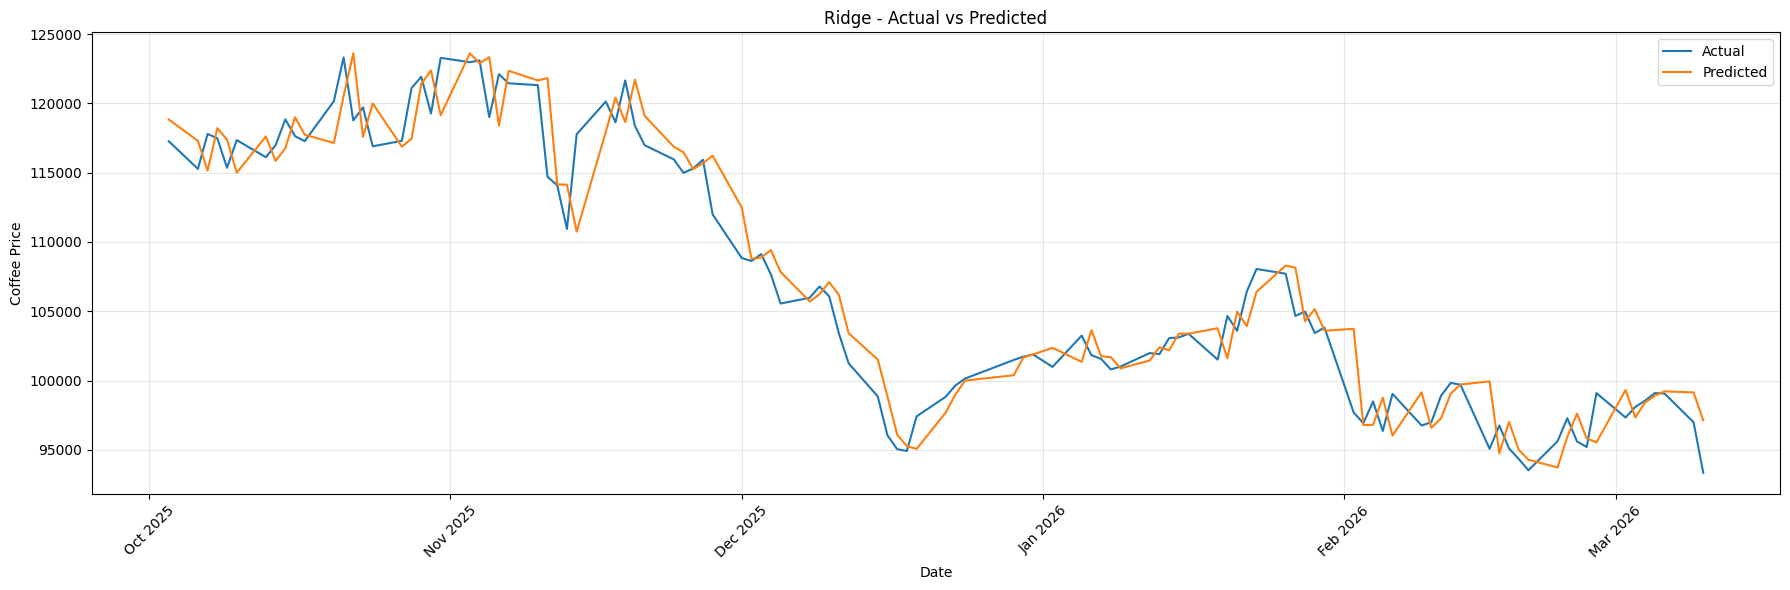

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_ridge,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("Ridge - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [14]:
# =========================
# CELL — ELASTIC NET
# =========================

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
elastic_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.2, 0.5, 0.8]
}

# =========================
# MODEL
# =========================
elastic_model = ElasticNet(
    max_iter=10000,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
elastic_grid = GridSearchCV(
    estimator=elastic_model,
    param_grid=elastic_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
elastic_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_elastic = elastic_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_elasticnet.pkl")
joblib.dump(best_elastic, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "elasticnet_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_elastic = best_elastic.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_elastic)
mse = mean_squared_error(y_test, pred_elastic)
rmse = np.sqrt(mse)

print("Best Params:", elastic_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.457e+07, tolerance: 2.662e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.732e+08, tolerance: 1.180e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.097e+09, tolerance: 2.766e

Model saved to: checkpoints/best_elasticnet.pkl
Scaler saved to: checkpoints/elasticnet_scaler.pkl
Best Params: {'alpha': 0.0001, 'l1_ratio': 0.8}
MAE  : 1748.7695
MSE  : 5257662.0895
RMSE : 2292.9592


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.023e+08, tolerance: 2.766e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.378e+09, tolerance: 4.651e+07
  model = cd_fast.enet_coordinate_descent(


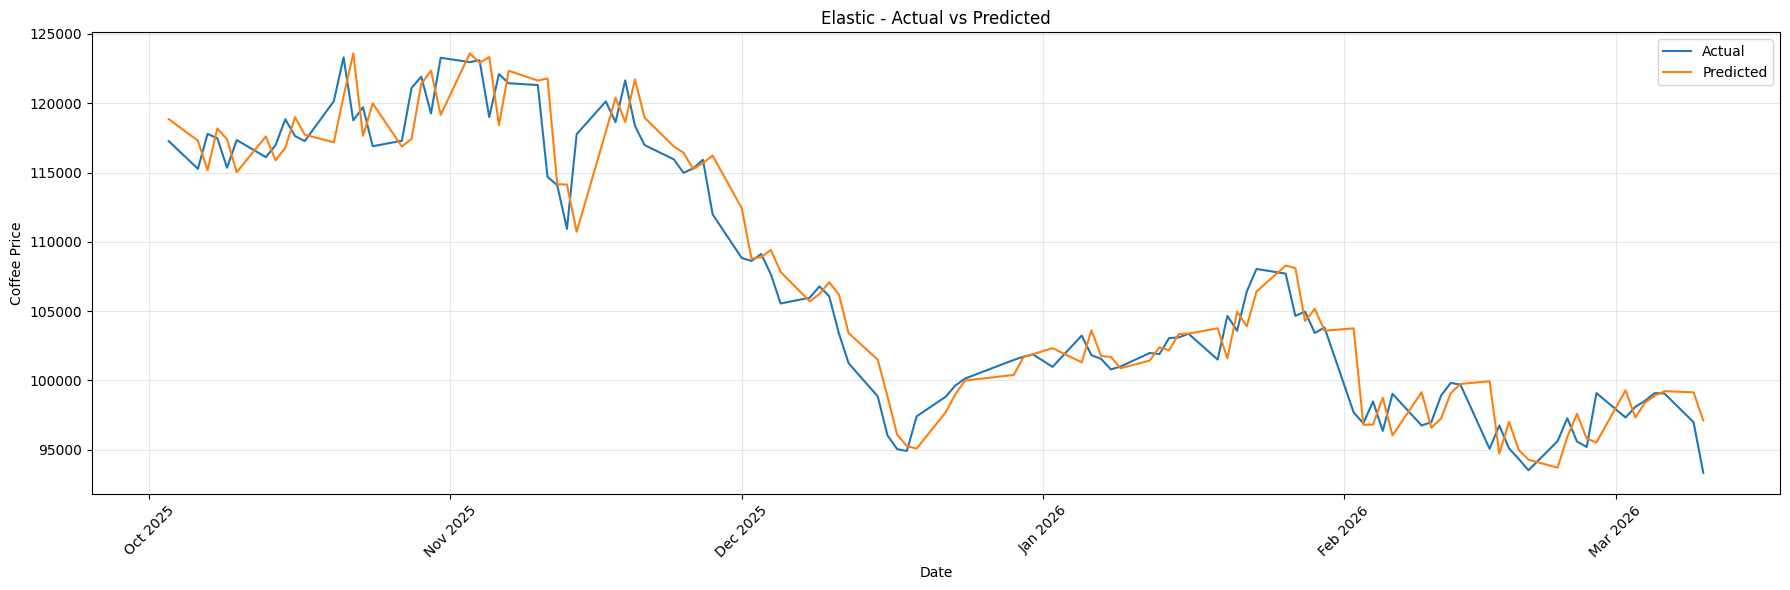

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_elastic,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("Elastic - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [16]:
# =========================
# CELL — SVM REGRESSION
# =========================

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import os

# =========================
# SCALE DATA
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# HYPERPARAMETER GRID
# =========================
svr_params = [
    # Linear SVM
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.001, 0.01, 0.1]
    },

    # Kernel SVM (RBF)
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.001, 0.01, 0.1],
        "gamma": ["scale", "auto"]
    }
]

# =========================
# MODEL
# =========================
svr_model = SVR()

# =========================
# GRID SEARCH
# =========================
svr_grid = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
svr_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_svr = svr_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_svr.pkl")
joblib.dump(best_svr, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "svr_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_svr = best_svr.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_svr)
mse = mean_squared_error(y_test, pred_svr)
rmse = np.sqrt(mse)

print("Best Params:", svr_grid.best_params_)
print(f"Best Kernel: {best_svr.kernel}")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model saved to: checkpoints/best_svr.pkl
Scaler saved to: checkpoints/svr_scaler.pkl
Best Params: {'C': 100, 'epsilon': 0.001, 'kernel': 'linear'}
Best Kernel: linear
MAE  : 1633.0983
MSE  : 4755589.3182
RMSE : 2180.7314


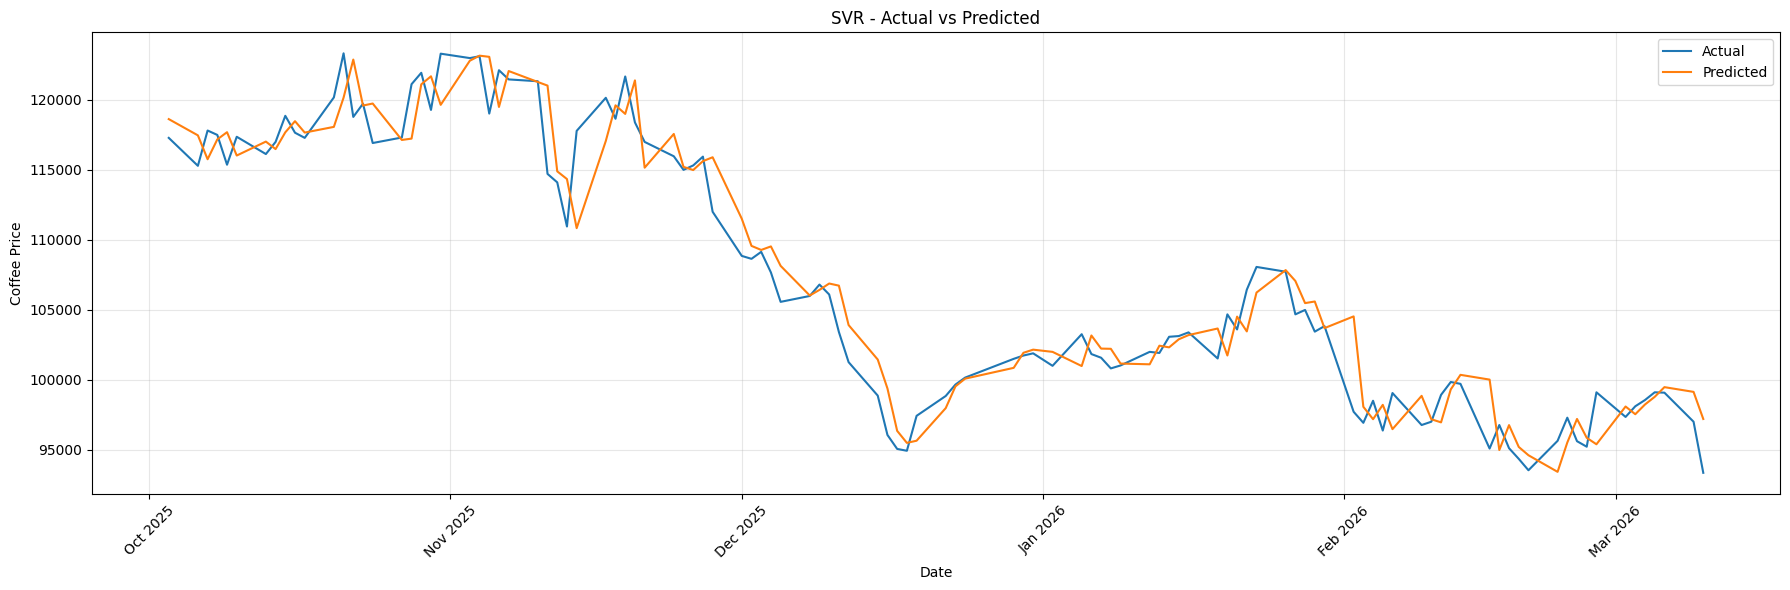

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Drop NaN
df = df.dropna().reset_index(drop=True)

# Lấy date tương ứng tập test
test_dates = df.iloc[train_size + val_size:]["date"]

plt.figure(figsize=(18,6))

# Actual
plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

# Predicted
plt.plot(
    test_dates,
    pred_svr,
    label="Predicted"
)

# Format hiển thị theo tháng
ax = plt.gca()

# Hiện mỗi tháng 1 lần
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Format: Jan 2025
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.title("SVR - Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()